# Tutorial . Análisis Básico de Electrooculograma con la clase EM  . 
### Daniel Yedra Cázares, Erin C. McKiernan, Marco Arieli Herrera-Valdez,
### Facultad de Ciencias, UNAM

## Tabla de contenidos:
[1. Introducción](#introduction)

[2. Clase EM ](#EM)

[2.1 Ejemplo de objeto EOG con sus métodos ](#CO)

[2.1.2 Registro de movimientos laterales](#RML)

[3. Resultados](#R)






## Introducción

El objetivo de este tutorial es mostrar cómo utilizar la clase EM (Electromiograma) para realizar un análisis específico de señales de Electrooculograma (EOG). Para ello, al igual que en el caso del análisis de EKG, se utilizará el atributo tipo, el cual nos permitirá adaptar e integrar métodos diseñados exclusivamente para el estudio del EOG.

A lo largo del tutorial se presentarán ejemplos básicos de uso, así como la resolución de algunas preguntas clave relacionadas con el comportamiento ocular, tales como:

	a)	¿Cómo podemos determinar la duración de los movimientos oculares?
    
	b)	¿Cuánto tiempo transcurre entre un movimiento y otro?
    
	c)	¿Qué tan veloz fue el desplazamiento ocular?

Estas preguntas guiarán el desarrollo del análisis, permitiendo una interpretación más profunda de los patrones oculares presentes en el registro.
    

<a id='introduction'></a>
## Inicialización del Notebook

Primero prepararemos el entorno adecuado para el notebook

In [1]:
# Librerias
import numpy as np
import random as rd
import wave
import sys
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from scipy.signal import butter, lfilter, filtfilt #fFiltrado de datos
from statistics import stdev
import scipy.stats as scs 
import seaborn as sns
import pandas as pd
sys.path.insert(1, r'./../functions') 

# Gráficas
%config InlineBackend.figure_formats = {'png', 'retina'} 
plt.rcParams['axes.labelsize'] = 16 
plt.rcParams['axes.titlesize'] = 18 
plt.rcParams['font.size'] = 14
plt.rcParams['lines.linewidth'] = 1.4 

<a id='EM'></a>
## Clase EM

In [2]:
from EOG_C import EM

<a id='C0'></a>
### Ejemplo de objeto EOG 

Para ilustrar la aplicación de los métodos desarrollados, se analizará un registro de Electrooculograma (EOG) que contiene movimientos oculares laterales (de un lado a otro). Este ejemplo permitirá demostrar paso a paso cómo detectar, segmentar y clasificar los eventos presentes en la señal.

<a id='RML'></a>
#### Registro de lado a lado

In [3]:
#Creamos un objeto EOG con un archivo .wav

#En este registro se realizaron movimientos de izquierda a derecha
EOG=EM(archivo='/Users/danielyedra/Desktop/Electro_fisio/electrophys/EOG/EOGbasics/data/S2_EOG_leftRight1.wav',tipo="EOG")

# Acceder a los atributos del objeto
print(f"Señal de la muestra: {EOG.señal}")
print(f"Tiempo de la señal: {EOG.vector_tiempo[-1]} segundos")
print(f'Tipo de registro: {EOG.get_tipo()}')
EOG.Descrip_est()

El registro tiene 1 canal(es).
La frecuencia de muestreo de la grabación es 10000 Hz.
Señal de la muestra: [ 301  357  362 ... -333 -268 -273]
Tiempo de la señal: 11.4131 segundos
Tipo de registro: EOG
Resumen Estadístico de la Señal EM:
  - Número de observaciones: 114131
  - Mínimo y máximo: (-2290, 3034)
  - Media: 132.3095
  - Varianza: 252084.8223
  - Asimetría: 0.5532
  - Curtosis: 4.5707


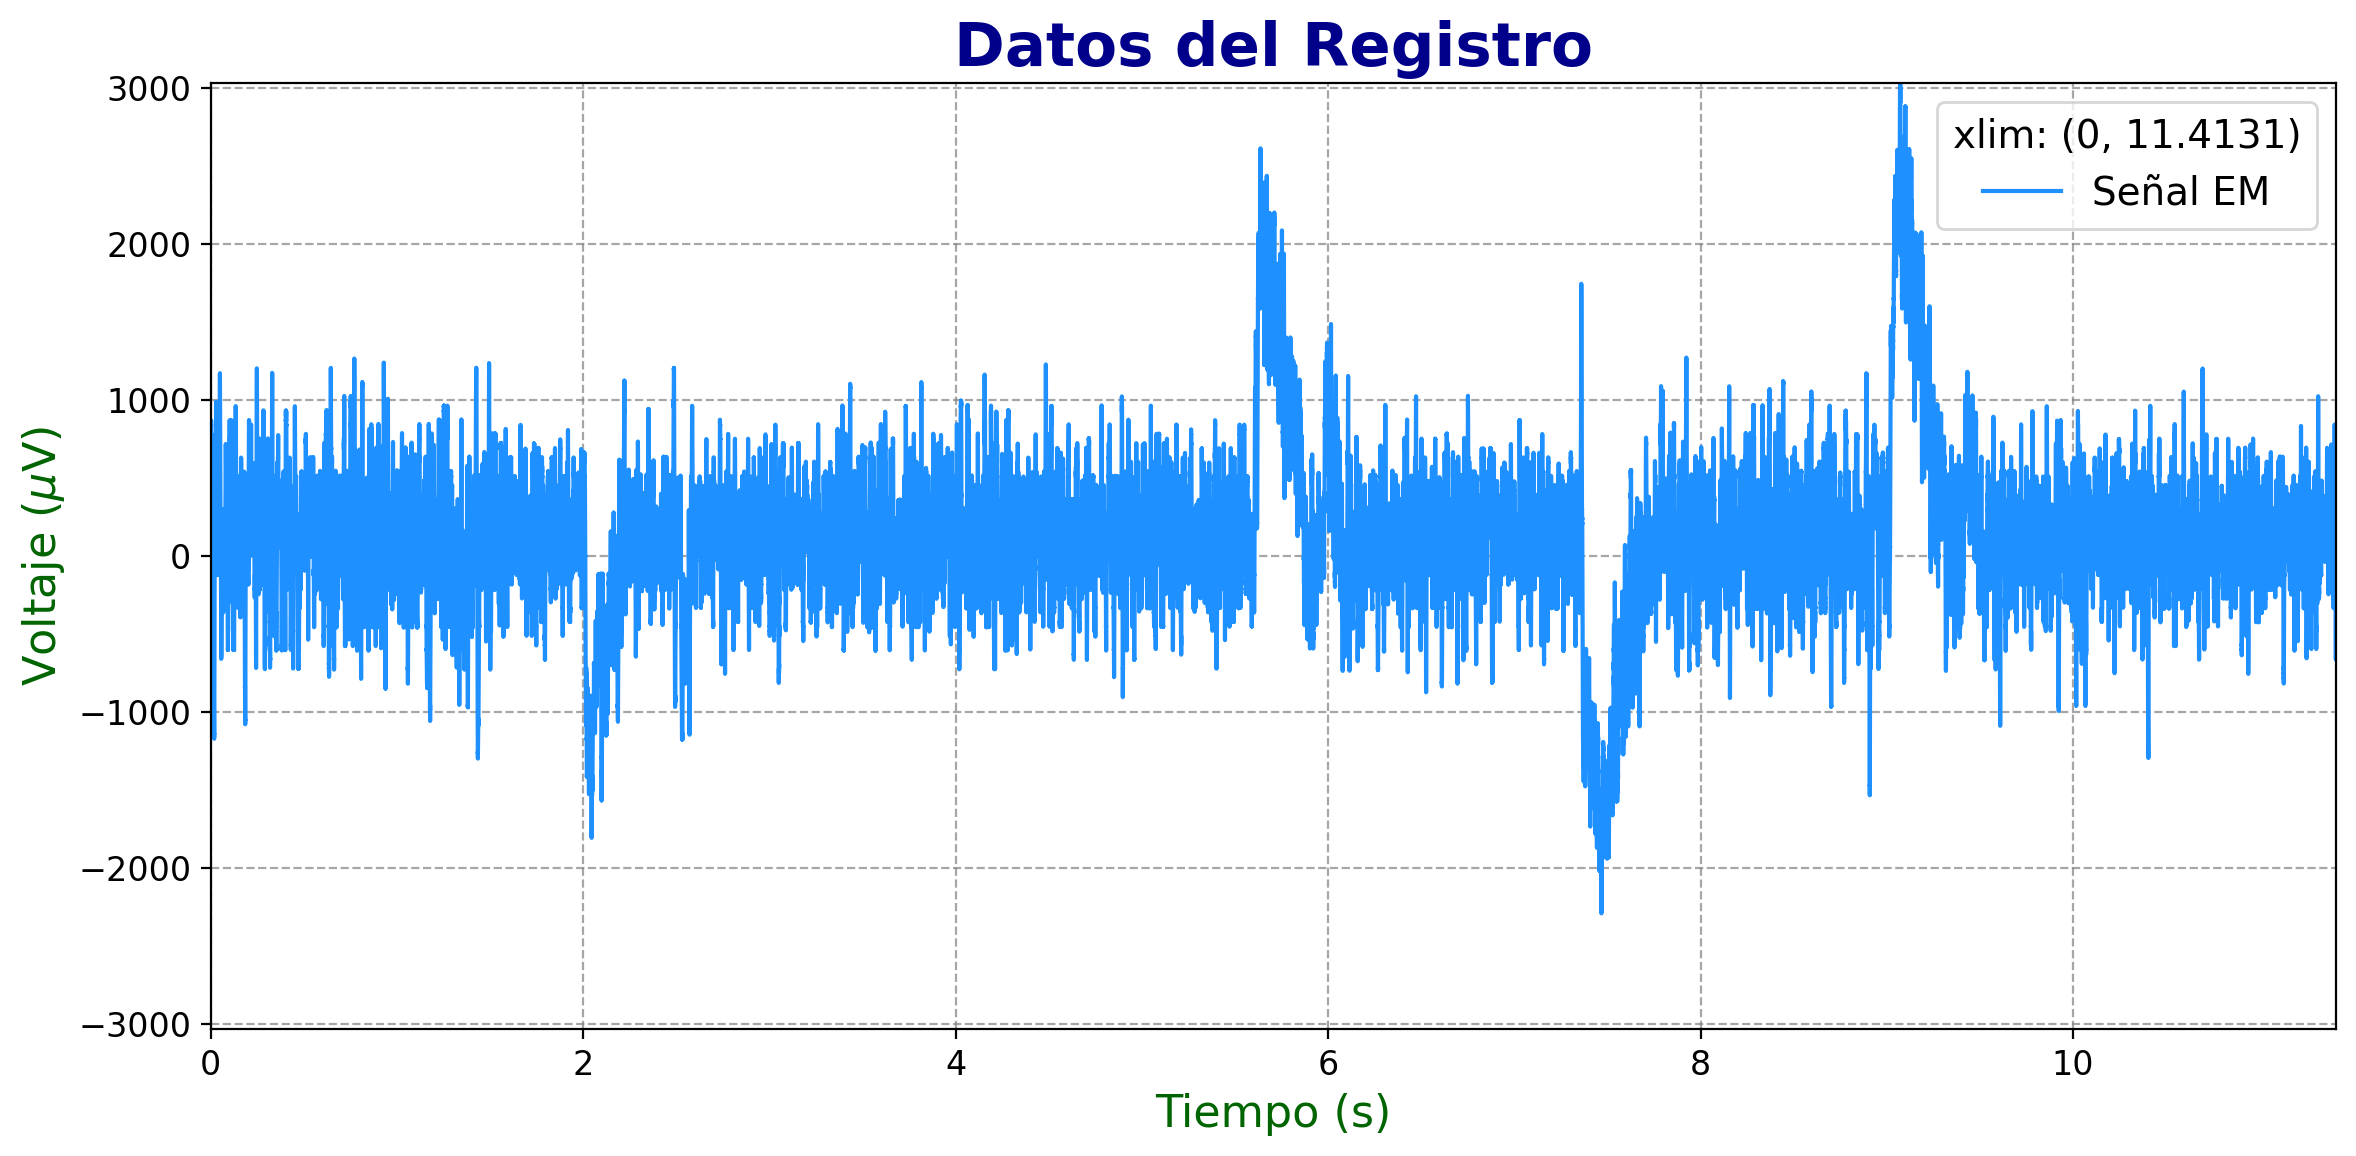

In [4]:
EOG.visualizar(0,max(EOG.vector_tiempo))

Ahora filtraremos el registro con el objetivo de atenuar el ruido presente en la señal, asegurándonos al mismo tiempo de preservar los picos característicos asociados a los movimientos oculares. Este paso es fundamental para mejorar la calidad del análisis y evitar que el ruido afecte la detección y clasificación de eventos.


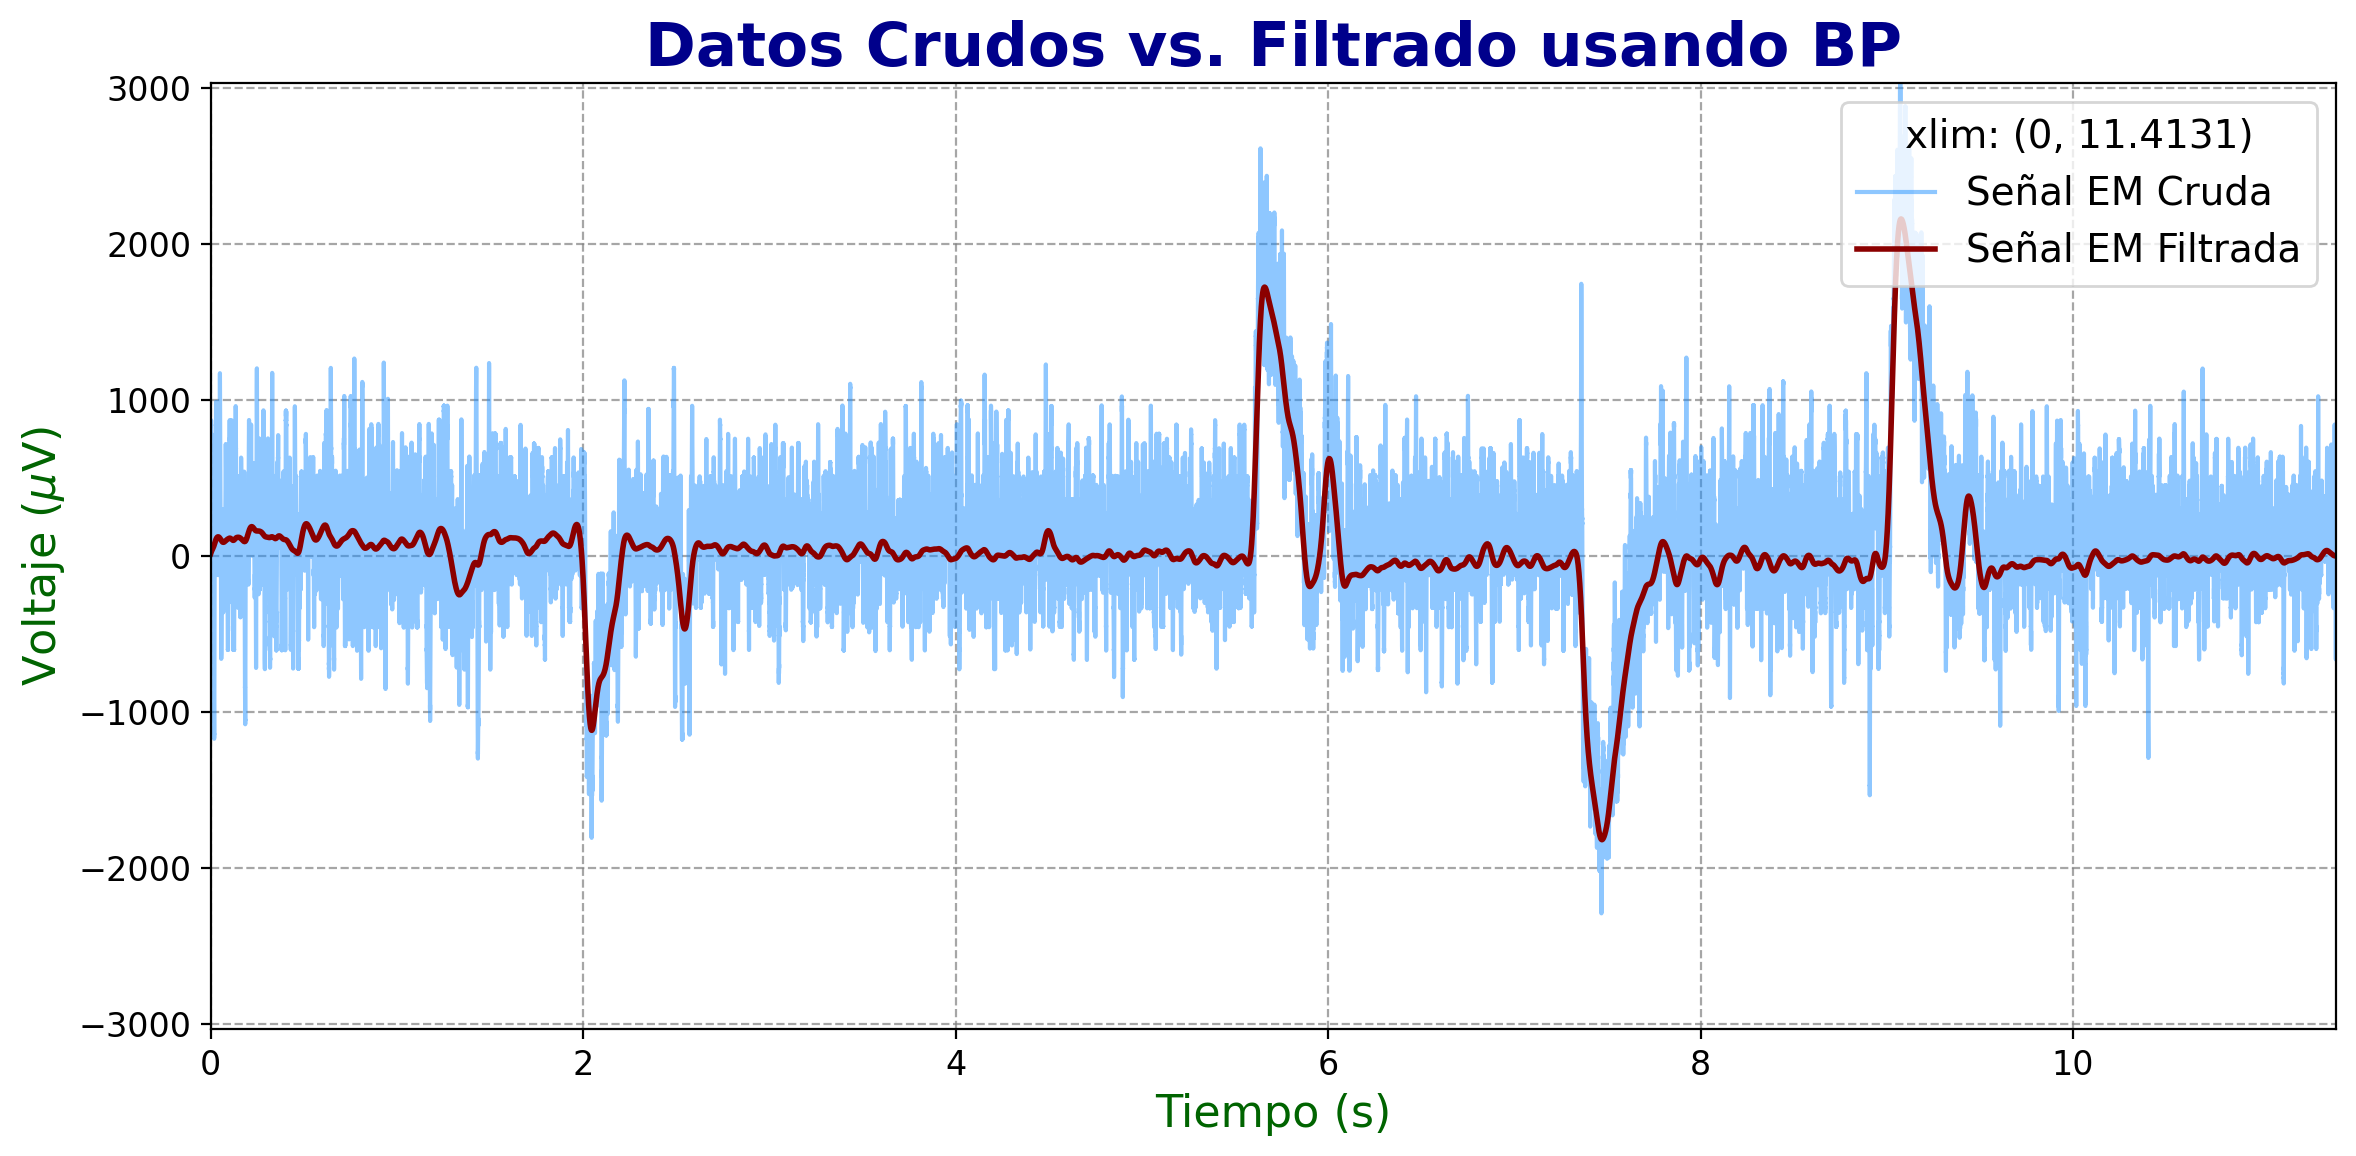

In [5]:
EOG.visualizar_filtrada( 0,max(EOG.vector_tiempo), low_cutoff=0.05, high_cutoff=10)

In [6]:
SF1=EOG.Señal_filtrada_Bandpass(low_cutoff=0.05,high_cutoff=10)
EOG_F=EM(señal=SF1,tasa_muestra=EOG.tasa_muestra,tipo='EOG')

Ahora vamos a utilizar los métodos específicos para el análisis de señales EOG. Antes de comenzar, es importante definir qué consideraremos como movimiento ocular en este contexto. En nuestro caso, un movimiento ocular se identifica como un cambio significativo dentro de una vecindad alrededor de los picos detectados en la señal.

Además, es importante mencionar que durante la creación del registro se siguió la siguiente metodología: tras realizar un movimiento ocular lateral, se mantuvo una fijación antes de regresar la mirada. Esta secuencia permite distinguir claramente entre las sacadas y los intervalos de fijación.

El procedimiento que seguimos se resume en los siguientes pasos:

1.	En primer lugar, se detectan los picos de la señal utilizando el método EOG.detectar_picos_por_vecindad(P=20000, umbral=1200, P_2=1500). Este método identifica los picos de la señal y los clasifica en positivos y negativos, lo cual permite analizar movimientos en ambos sentidos.

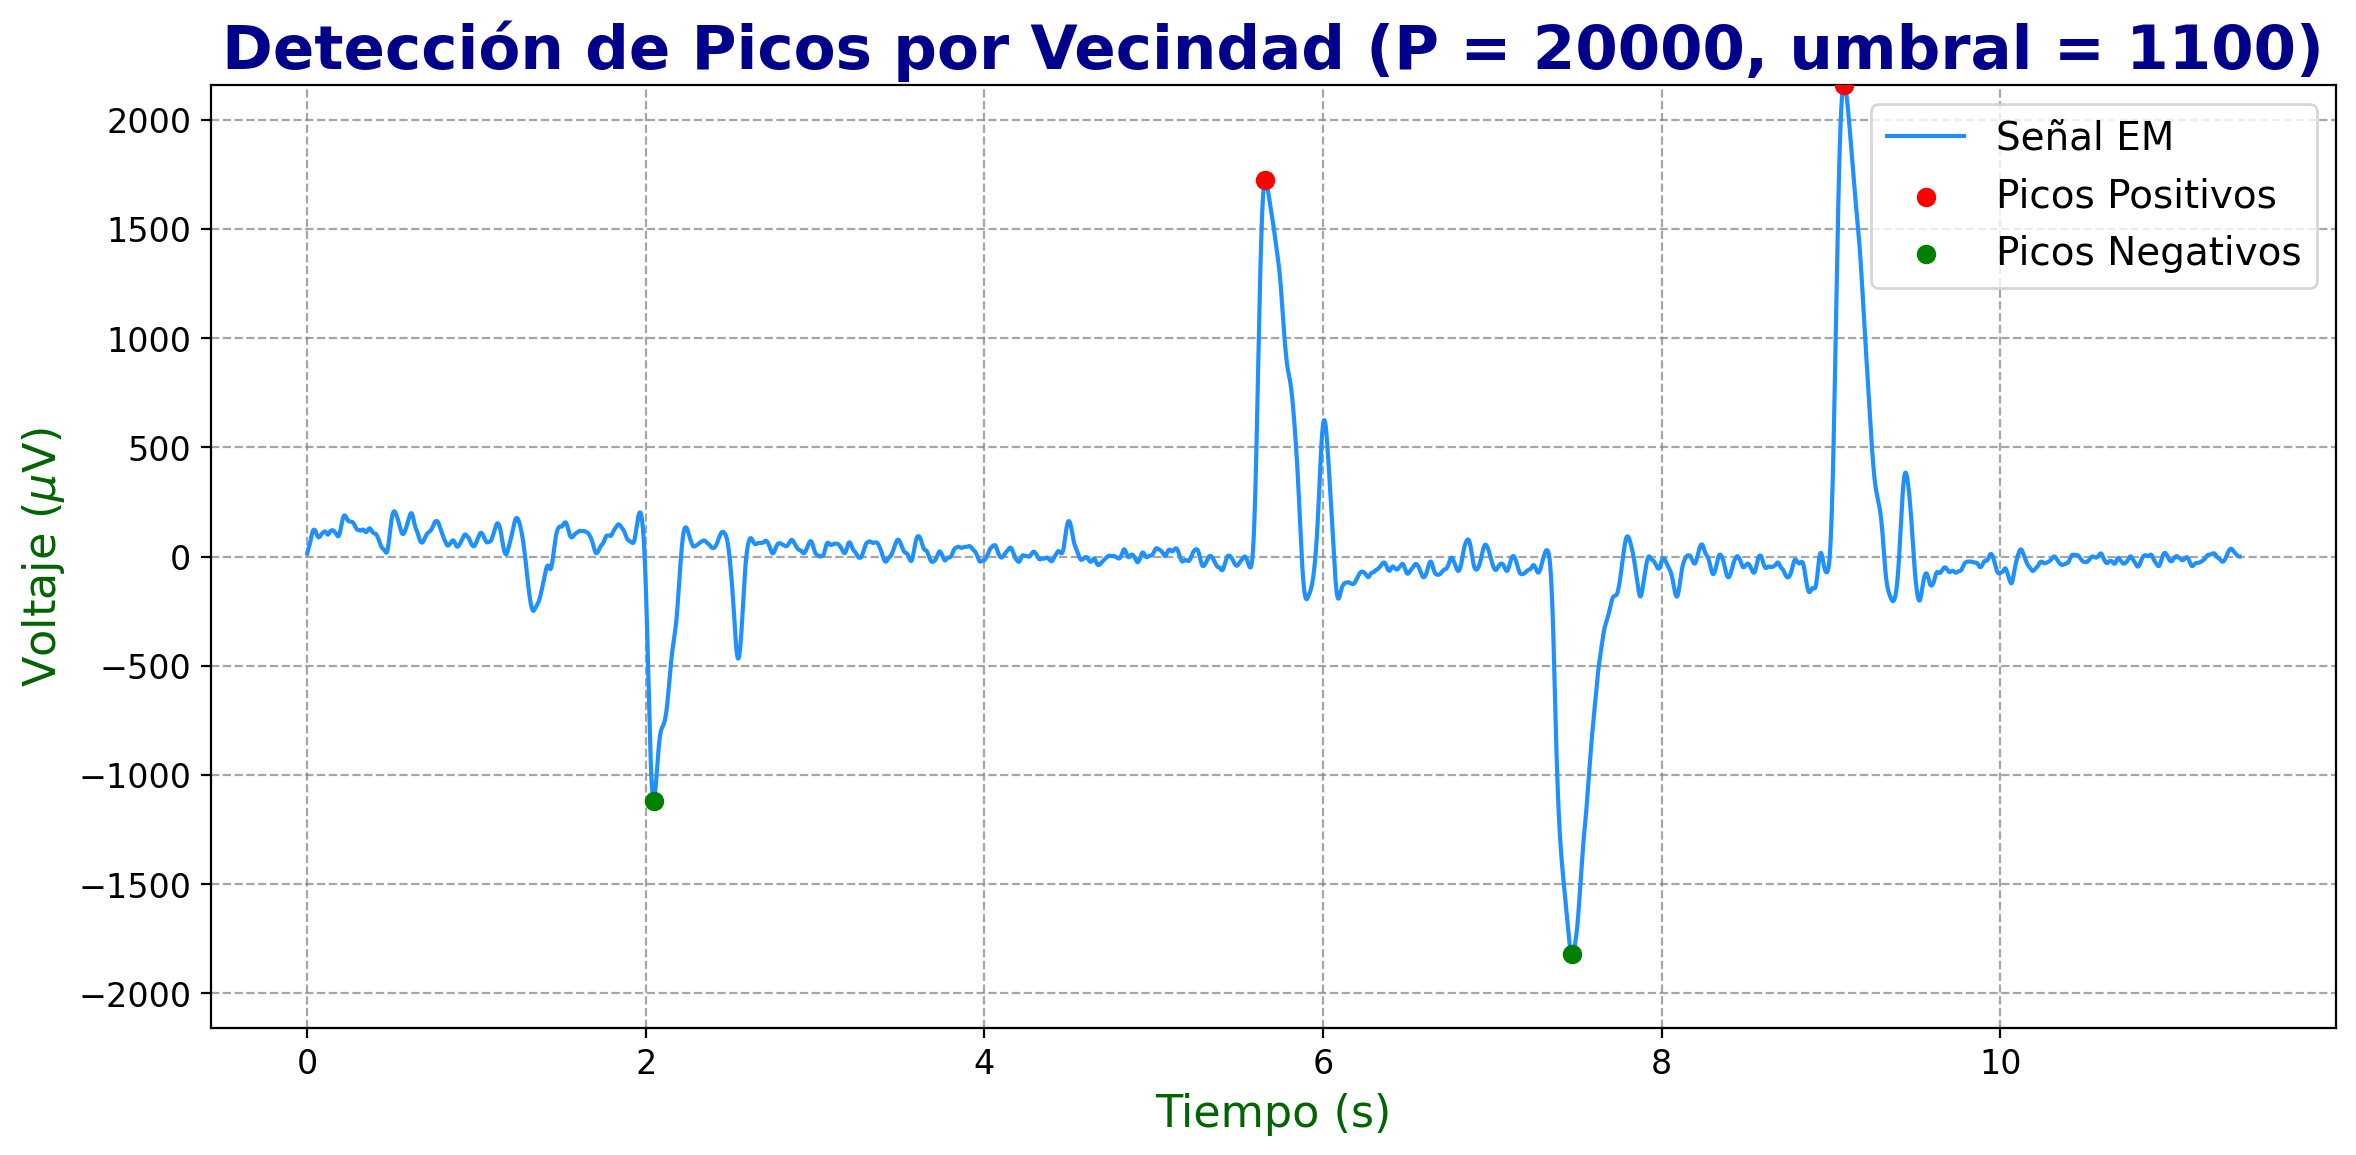

In [7]:
A=EOG_F.detectar_picos_por_vecindad(P=20000, umbral=1100)

2.	Una vez identificados los picos, el siguiente paso consiste en delimitar la vecindad temporal en la que ocurre el movimiento ocular. Existen diversas formas de definir estos intervalos, sin embargo, en este análisis optamos por una estrategia simple, basada en los cruces por cero. Es decir, consideramos que el inicio y fin de un movimiento ocular se encuentran en los puntos donde la señal cruza el eje horizontal alrededor de cada pico detectado.

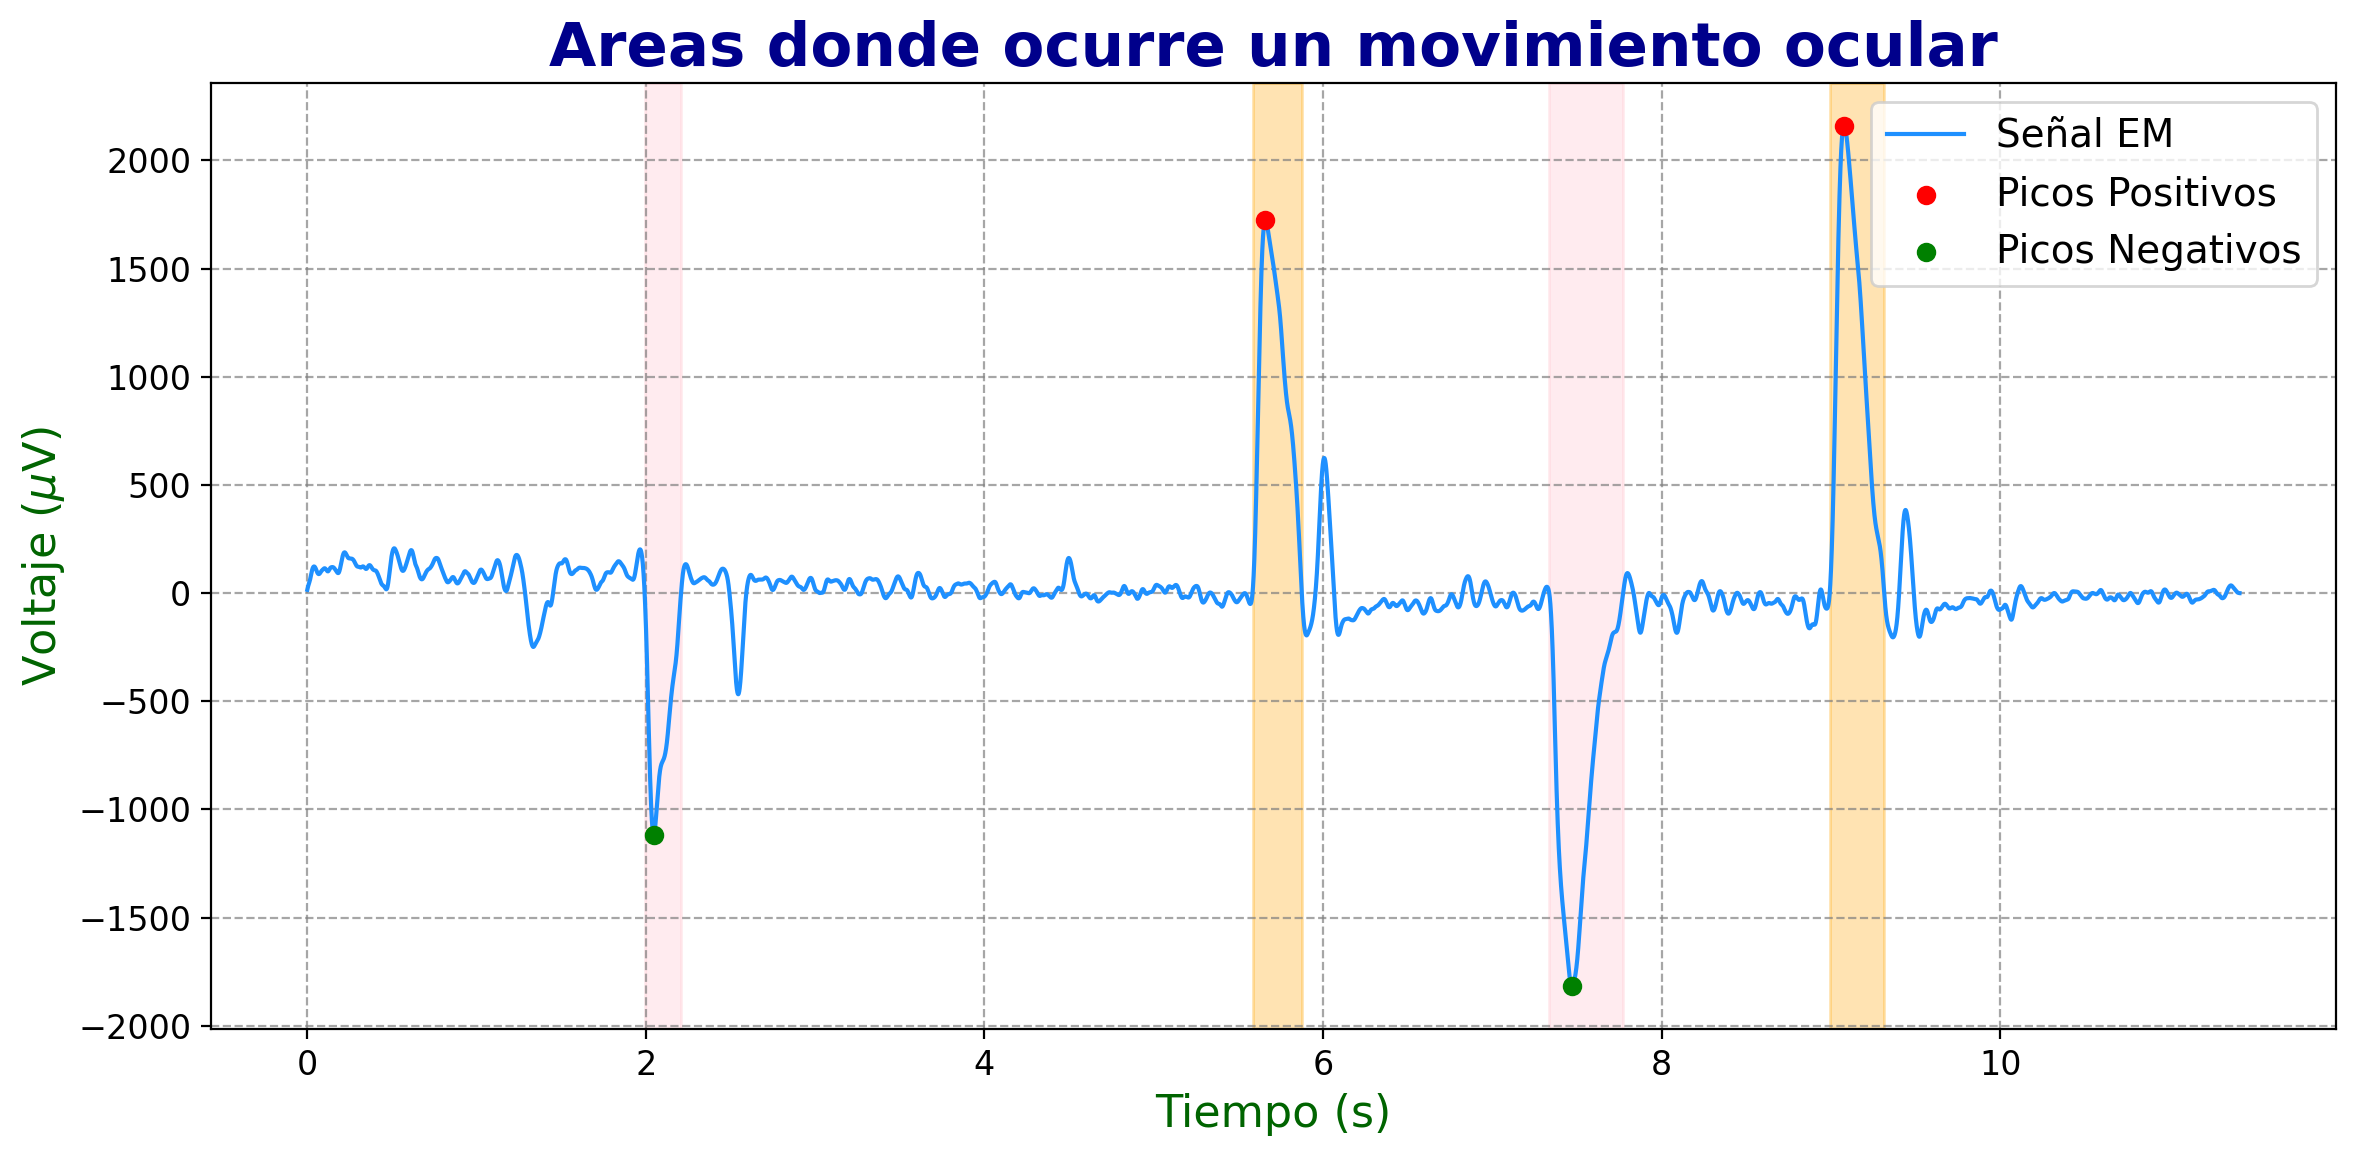

In [8]:
B=EOG_F.encontrar_bordes_vecindad_cero(picos_positivos=A[0], picos_negativos=A[1],P=20000, umbral=1200)

3.	Con las vecindades definidas, ahora es posible extraer información relevante asociada a cada movimiento ocular. A partir de estos intervalos, se obtienen parámetros clave como la amplitud, duración, velocidad y frecuencia de los movimientos, los cuales permiten caracterizar y clasificar los eventos presentes en el registro de manera más precisa.

    Además cabe resaltar que estos datos estan en función del voltaje no grados visuales.

In [9]:
C=EOG_F.analizar_movimientos_oculares_por_vecindad(bordes_positivos=B[0], bordes_negativos=B[1])

   Inicio (s)  Fin (s)  Amplitud (uV)  Duración (s)  Velocidad (uV/s)  \
0       1.993    2.208       1118.262         0.215          5198.757   
1       5.583    5.874       1724.102         0.291          5928.772   
2       7.336    7.772       1818.095         0.436          4166.084   
3       8.992    9.315       2160.966         0.322          6708.933   

   Frecuencia (Hz)  
0            0.000  
1            0.279  
2            0.571  
3            0.604  


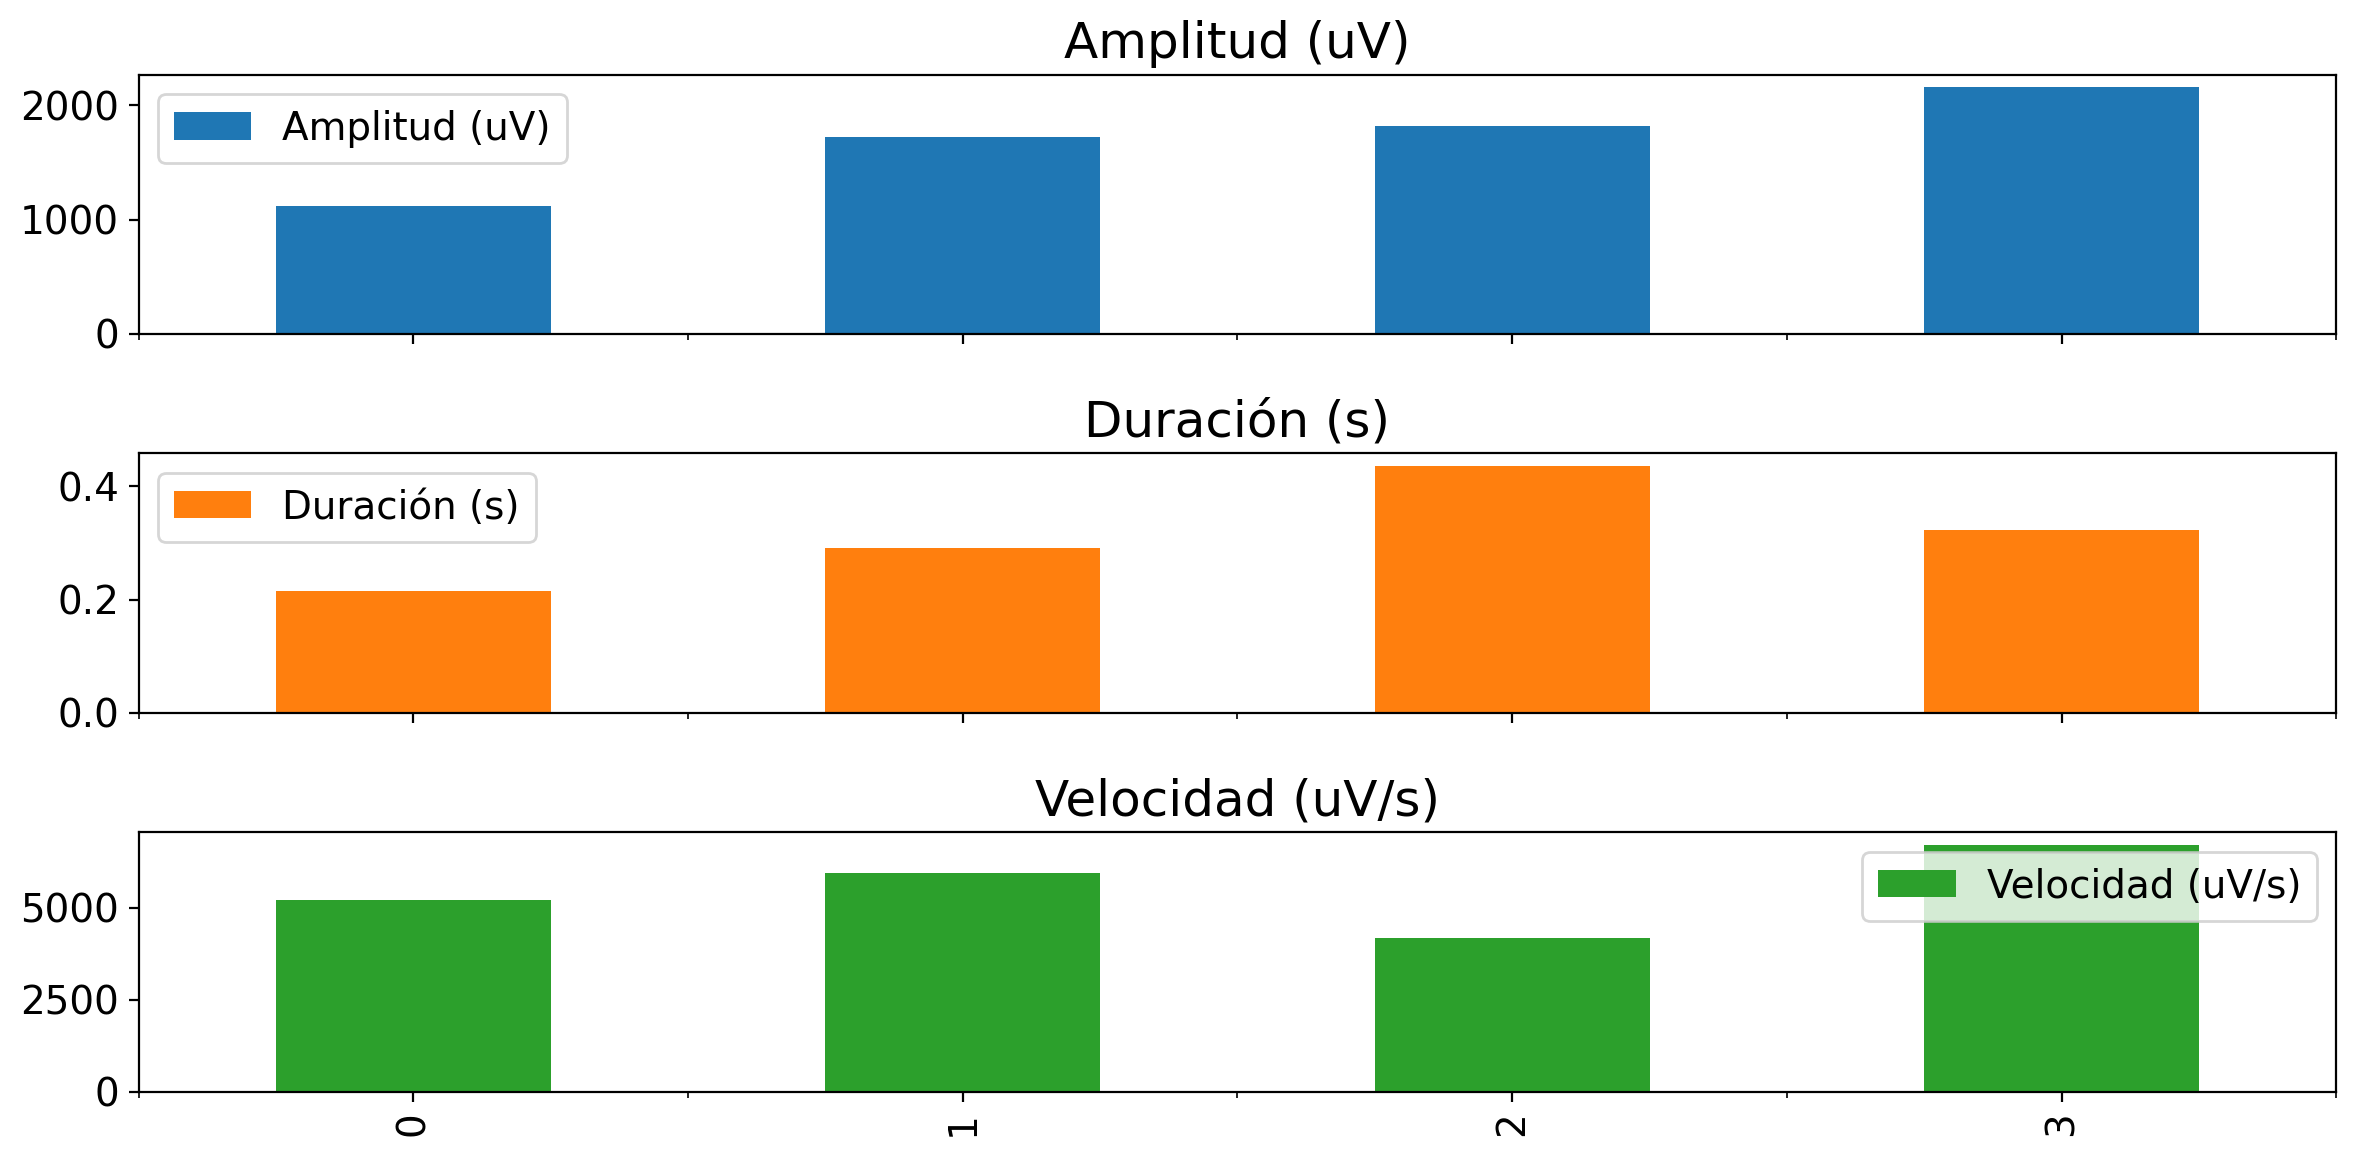

In [10]:
C.plot(kind='bar', y=['Amplitud (uV)', 'Duración (s)', 'Velocidad (uV/s)'], figsize=(12, 6), subplots=True)
plt.tight_layout()
plt.show()

4. A partir de los datos obtenidos en el paso anterior, se establece una clasificación heurística de los movimientos oculares. Esta clasificación se basa en umbrales definidos para variables como la amplitud, duración y velocidad, permitiendo distinguir entre distintos tipos de movimientos, tales como sacadas, microsacadas, fijaciones y parpadeos, de acuerdo con sus características fisiológicas y patrones observados en la señal.

##### Criterio Heuristico para la Clasificación de Movimientos Oculares (EOG)

| Tipo de Movimiento     | Condición (Amplitud, Duración, Velocidad)                  | Justificación |
|------------------------|-------------------------------------------------------------|---------------|
| **Sacada**             | Amplitud > 800 μV, Velocidad > 3500 μV/s, Duración ≤ 0.5 s  | Movimiento ocular rápido con cambio brusco de voltaje, típico de cambio de fijación visual. |
| **Microsacada**        | Amplitud < 800 μV, Duración < 0.08 s                        | Pequeños ajustes de la mirada, común durante fijaciones prolongadas. |
| **Fijación**           | Amplitud < 600 μV, Velocidad < 2000 μV/s, Duración ≥ 0.25 s | Período de estabilidad visual, el ojo permanece casi inmóvil captando información. |
| **Parpadeo**           | Amplitud > 2500 μV, Velocidad > 10000 μV/s, Duración < 0.4s     | Artefacto generado por cierre rápido de párpados, produce pico muy alto en EOG. |
| **Indefinido**         | No cumple ninguna de las condiciones anteriores             | Podría ser ruido o combinación atípica, requiere análisis más profundo. |

Conteo de tipos de movimientos:
Tipo de Movimiento
Sacada    4
Name: count, dtype: int64


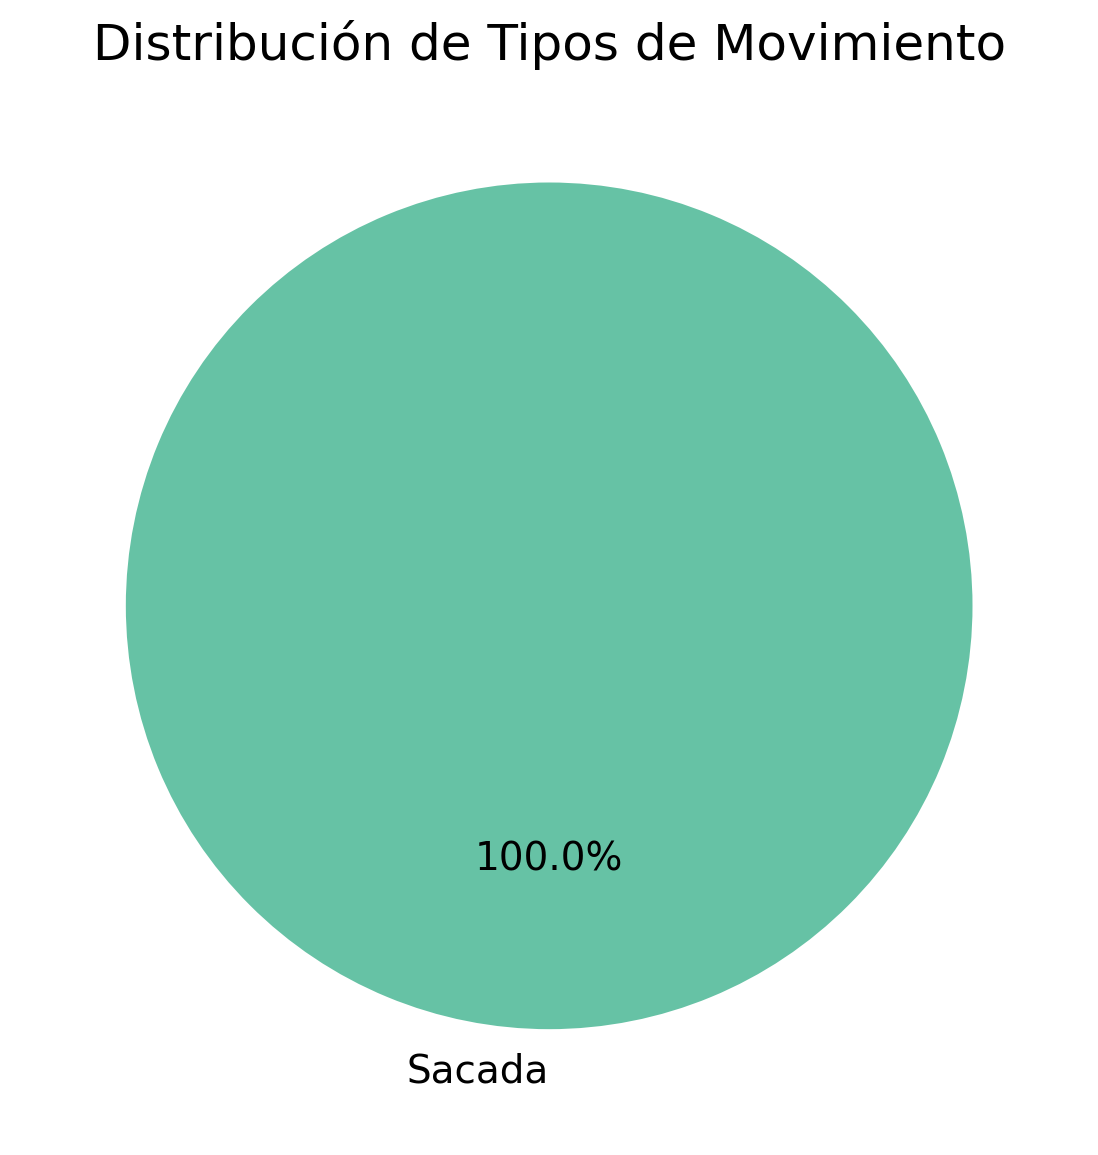

In [11]:
D=EOG_F.clasificar_y_visualizar_movimientos(C)

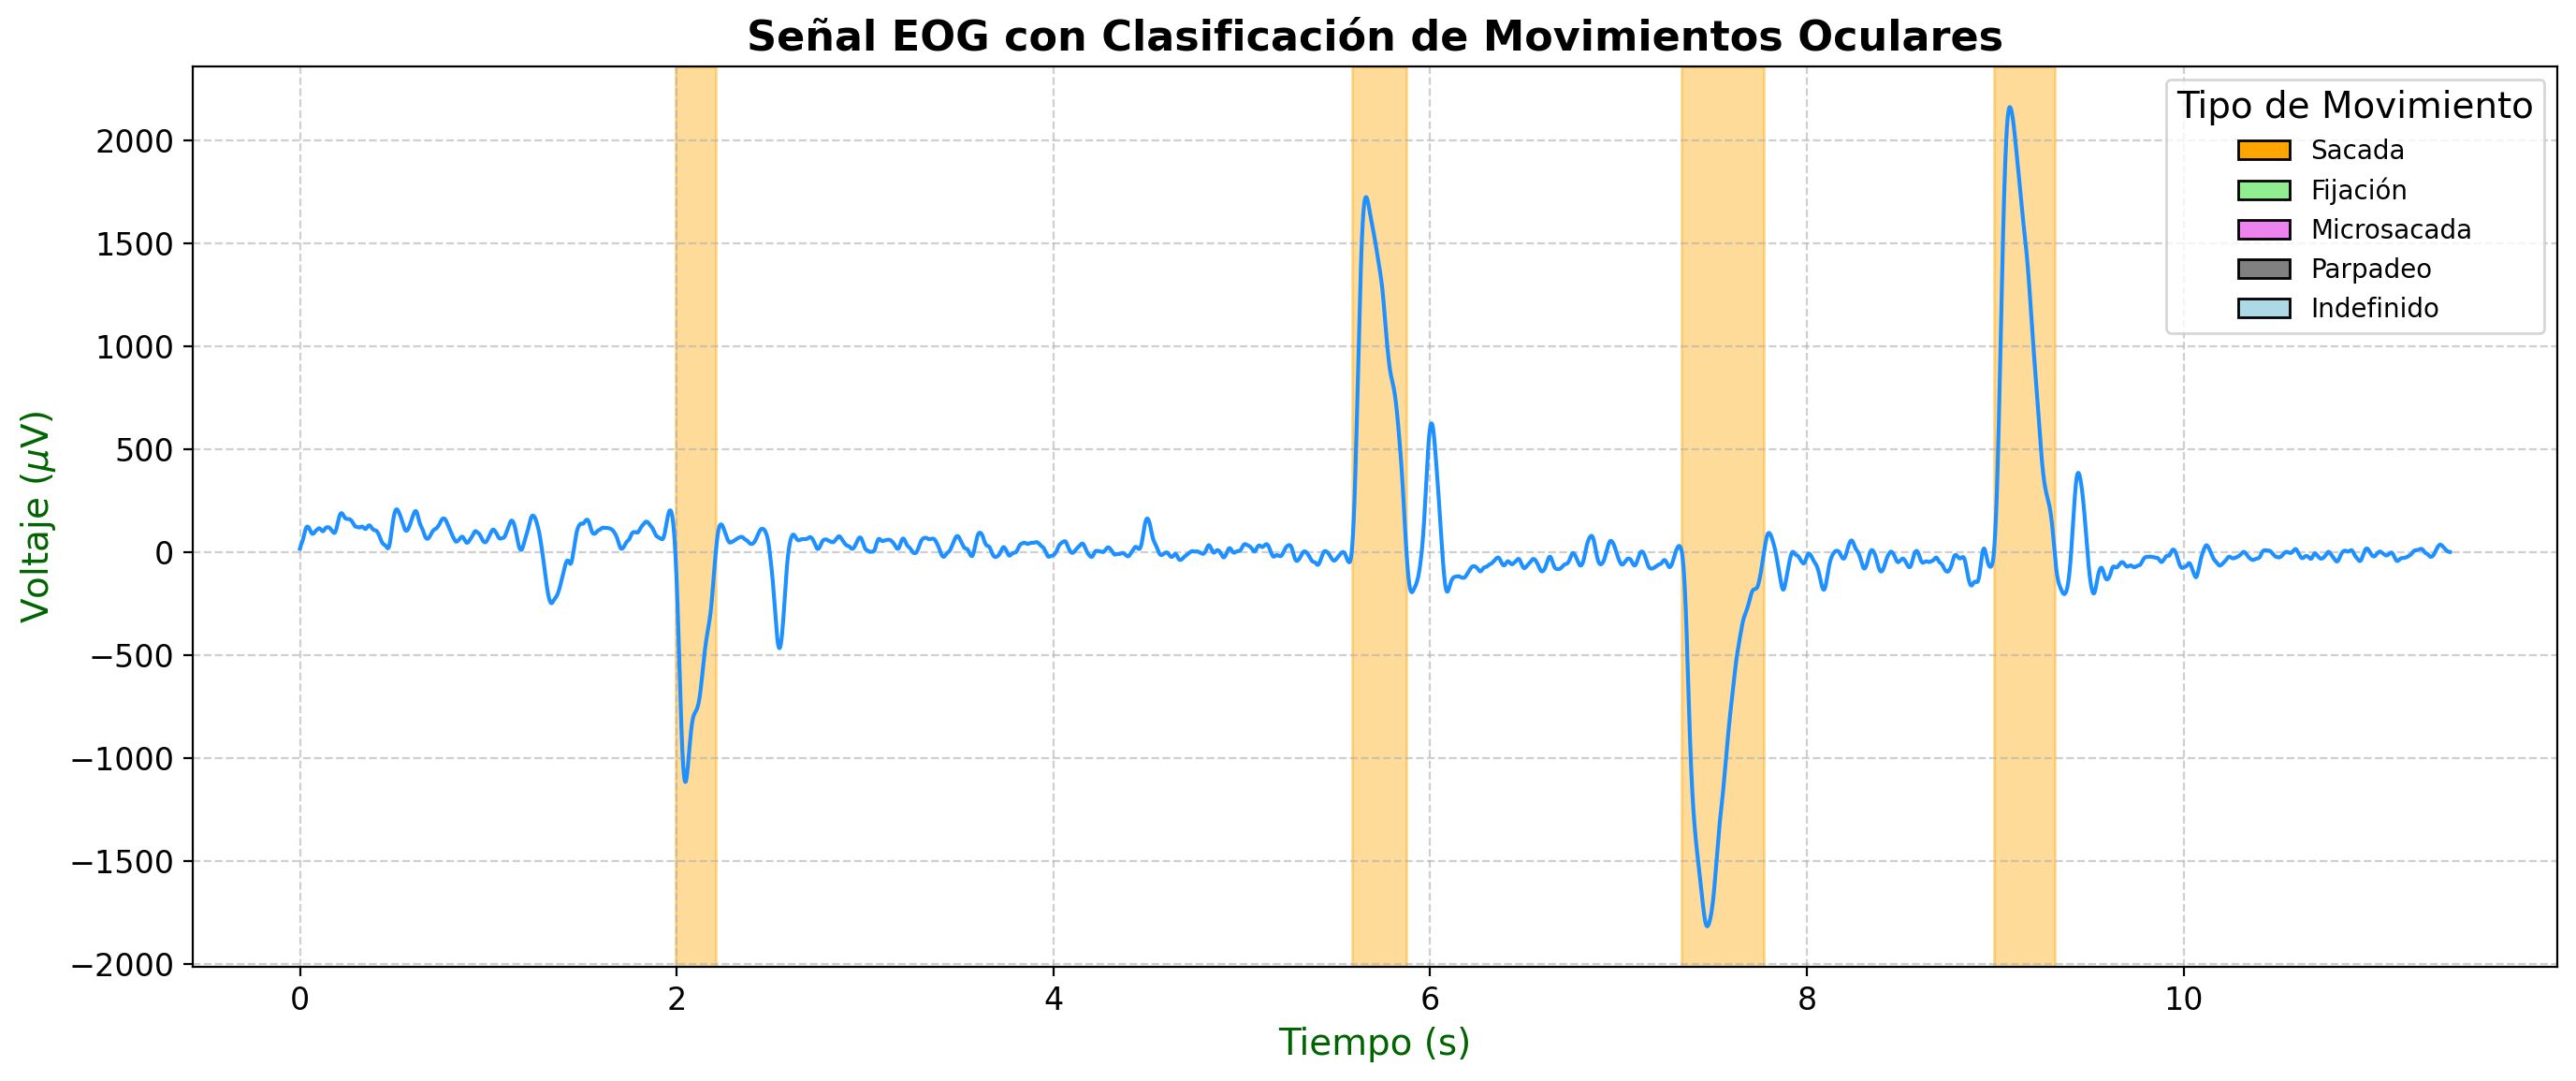

In [12]:
EOG_F.graficar_movimientos_clasificados(C)

5.	Una vez realizada la clasificación general de los movimientos oculares, surge una pregunta clave: ¿qué ocurre en los intervalos entre dichos movimientos? Para abordar esta cuestión, se implementaron métodos adicionales que permiten analizar los segmentos de señal comprendidos entre eventos clasificados, con el objetivo de identificar posibles fijaciones implícitas u otros patrones de comportamiento ocular relevantes.

In [13]:
E=EOG_F.agregar_fijaciones_entre_eventos(df_movimientos=D)

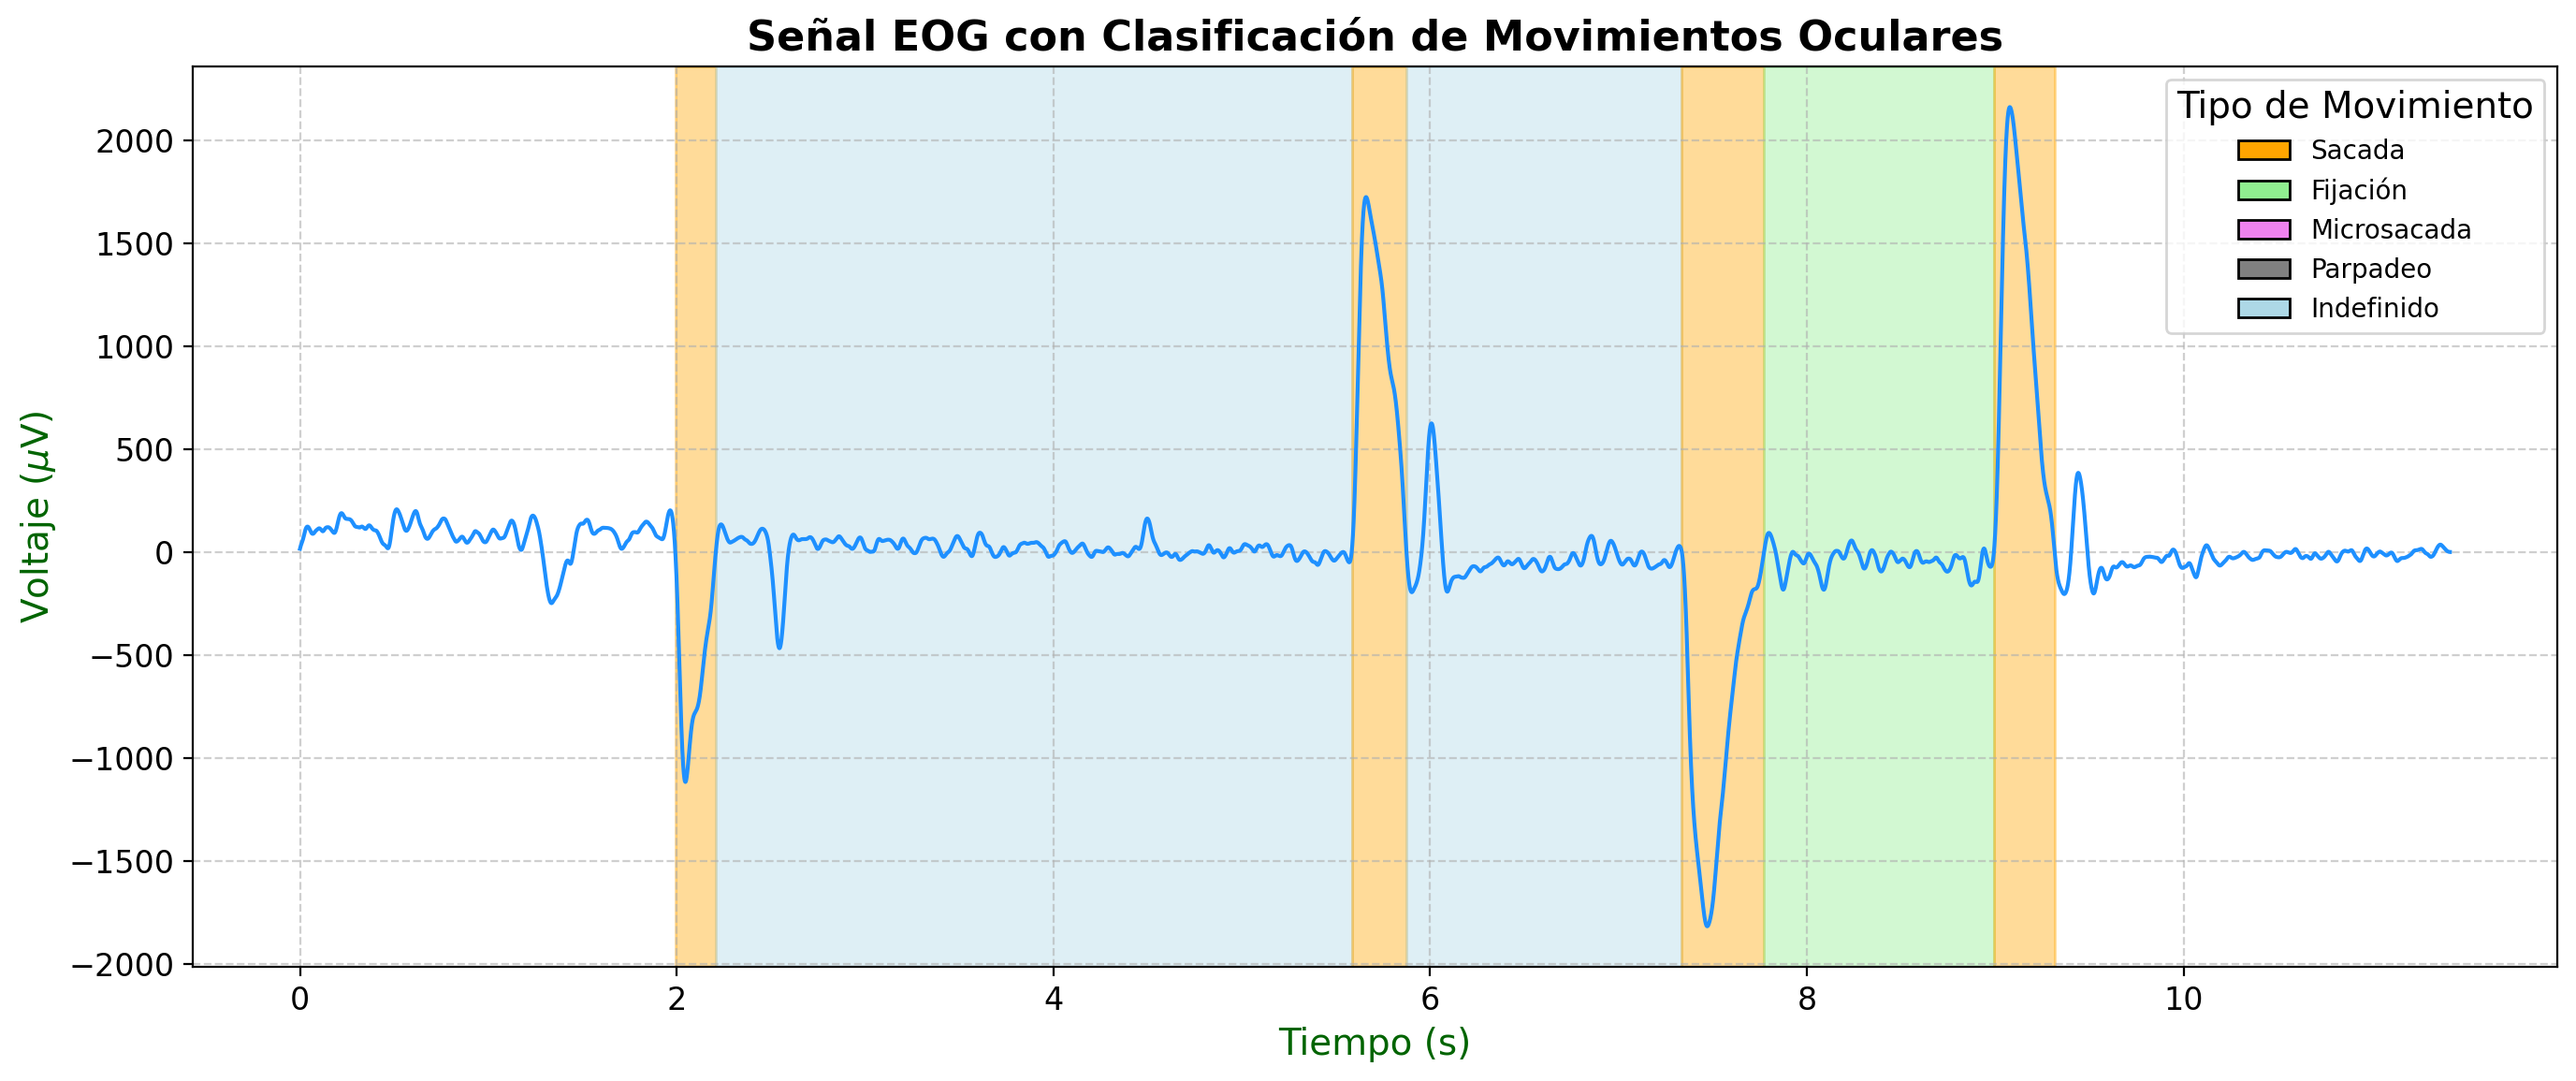

In [14]:
EOG_F.graficar_movimientos_clasificados(df=E)

A partir de la gráfica obtenida, observamos que dos de los tres intervalos entre sacadas fueron clasificados como “Indefinidos” según los criterios actuales. Sin embargo, esta clasificación probablemente se deba a la presencia de picos de amplitud considerable dentro de dichos intervalos, lo cual eleva los valores de velocidad y amplitud por encima de los umbrales establecidos para una fijación.

Es importante destacar que, si se relajaran ligeramente las condiciones del clasificador, particularmente los límites de amplitud y velocidad, estos intervalos podrían ser reconocidos como fijaciones, ya que corresponden a momentos donde la mirada permaneció relativamente estable tras el movimiento ocular.

<a id='R'></a>
### Resultados

Una vez realizado el análisis básico, ya estamos en condiciones de responder las preguntas planteadas al inicio del cuaderno:

    a) ¿Cómo podemos determinar la duración de los movimientos oculares?
    La duración se obtiene delimitando una vecindad alrededor de cada pico detectado. En este caso, utilizamos como criterio el cruce por cero (paso 2), lo que nos permite identificar el inicio y fin del movimiento. No obstante, también podrían definirse vecindades más complejas si se desea un análisis más preciso.

    b) ¿Cuánto tiempo transcurre entre un movimiento y otro?
    Este dato se obtiene midiendo la duración de los segmentos de señal entre vecindades consecutivas. Estos intervalos representan el tiempo en que la mirada permanece estable o fija antes de iniciar un nuevo movimiento.

    c) ¿Qué tan veloz fue el movimiento ocular?
    La velocidad se calcula como el cociente entre la amplitud y la duración del movimiento (velocidad = amplitud / duración). Aunque esta medida está en términos de voltaje (μV/s) y no en grados visuales, una velocidad alta puede interpretarse como un movimiento más brusco o rápido de los ojos.

Otras preguntas que podemos abordar con el análisis:

	•¿Cuál es la frecuencia de aparición de los movimientos oculares?
	•¿Cuál es la velocidad media y máxima registrada?
	•¿Cuál es la amplitud típica de las sacadas?
	•¿Qué porcentaje del tiempo total corresponde a fijaciones y cuánto a movimientos?
	•¿Existen anomalías o movimientos atípicos que no cumplen los patrones esperados?


Finalmente, es importante reflexionar sobre la confiabilidad de los eventos detectados. La presencia de movimientos clasificados como “Indefinidos” o el mal ajuste de los parámetros de clasificación podrían indicar la necesidad de ajustar los umbrales o aplicar técnicas de preprocesamiento adicionales para mejorar la precisión del análisis.